In [2]:
from scipy.io import arff
import pandas as pd

# 1. Charger le fichier .arff depuis ton dossier data
data, meta = arff.loadarff('../data/bone-marrow.arff')

# 2. Convertir en DataFrame Pandas pour pouvoir travailler dessus
df = pd.DataFrame(data)

# 3. Nettoyer les chaînes de caractères (le format arff ajoute des 'b' devant les textes)
df = df.apply(lambda x: x.str.decode('utf8') if x.dtype == "object" else x)

# Afficher les 5 premières lignes
df.head()

,Recipientgender,Stemcellsource,Donorage,Donorage35,IIIV,Gendermatch,DonorABO,RecipientABO,RecipientRh,ABOmatch,...,extcGvHD,CD34kgx10d6,CD3dCD34,CD3dkgx10d8,Rbodymass,ANCrecovery,PLTrecovery,time_to_aGvHD_III_IV,survival_time,survival_status
1,1,1,22.830137,0,1,0,1,1,1,0,...,1,7.20,1.338760,5.38,35.0,19.0,51.0,32.0,999.0,0.0
2,1,0,23.342466,0,1,0,-1,-1,1,0,...,1,4.50,11.078295,0.41,20.6,16.0,37.0,1000000.0,163.0,1.0
3,1,0,26.394521,0,1,0,-1,-1,1,0,...,1,7.94,19.013230,0.42,23.4,23.0,20.0,1000000.0,435.0,1.0
4,0,0,39.684932,1,1,0,1,2,1,1,...,?,4.25,29.481647,0.14,50.0,23.0,29.0,19.0,53.0,1.0
5,0,1,33.358904,0,0,0,1,2,0,1,...,1,51.85,3.972255,13.05,9.0,14.0,14.0,1000000.0,2043.0,0.0


In [19]:
# On ne garde que les colonnes numériques pour la corrélation
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# Afficher la matrice
print(corr_matrix)

                      Donorage  Recipientage  CD34kgx10d6  CD3dCD34  \
Donorage              1.000000      0.094282     0.072530  0.144919   
Recipientage          0.094282      1.000000    -0.454347  0.053913   
CD34kgx10d6           0.072530     -0.454347     1.000000 -0.130573   
CD3dCD34              0.144919      0.053913    -0.130573  1.000000   
CD3dkgx10d8           0.023555     -0.430737     0.583284 -0.370918   
Rbodymass             0.106707      0.897538    -0.465137  0.061390   
ANCrecovery          -0.005872      0.114914    -0.086835  0.024662   
PLTrecovery          -0.056949      0.101815    -0.180256 -0.010890   
time_to_aGvHD_III_IV  0.016548      0.136641     0.010245  0.030236   
survival_time         0.005603     -0.137583     0.139313  0.044016   
survival_status       0.060384      0.203406    -0.146653  0.089868   

                      CD3dkgx10d8  Rbodymass  ANCrecovery  PLTrecovery  \
Donorage                 0.023555   0.106707    -0.005872    -0.056949   

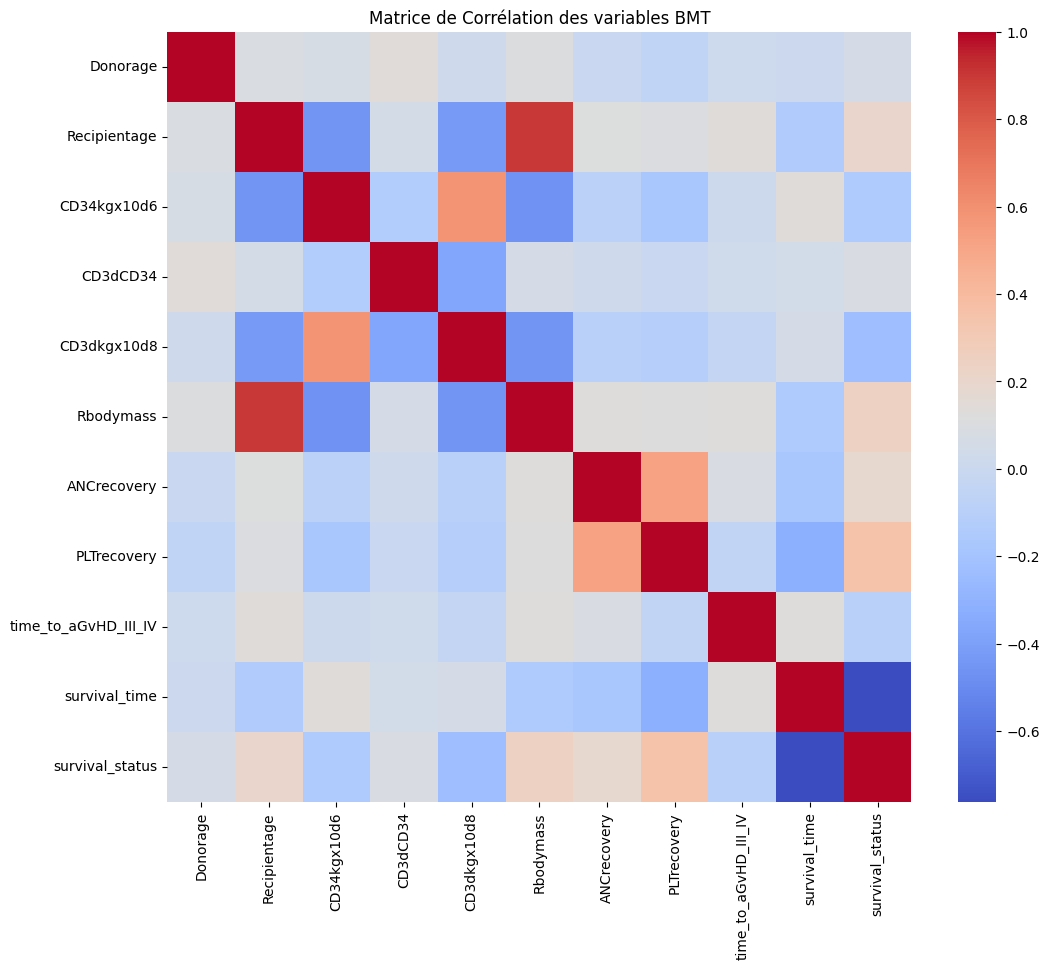

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation des variables BMT")
plt.show()

In [21]:
# On ne garde que les colonnes numériques pour la corrélation
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# Afficher la matrice
print(corr_matrix)

                      Donorage  Recipientage  CD34kgx10d6  CD3dCD34  \
Donorage              1.000000      0.094282     0.072530  0.144919   
Recipientage          0.094282      1.000000    -0.454347  0.053913   
CD34kgx10d6           0.072530     -0.454347     1.000000 -0.130573   
CD3dCD34              0.144919      0.053913    -0.130573  1.000000   
CD3dkgx10d8           0.023555     -0.430737     0.583284 -0.370918   
Rbodymass             0.106707      0.897538    -0.465137  0.061390   
ANCrecovery          -0.005872      0.114914    -0.086835  0.024662   
PLTrecovery          -0.056949      0.101815    -0.180256 -0.010890   
time_to_aGvHD_III_IV  0.016548      0.136641     0.010245  0.030236   
survival_time         0.005603     -0.137583     0.139313  0.044016   
survival_status       0.060384      0.203406    -0.146653  0.089868   

                      CD3dkgx10d8  Rbodymass  ANCrecovery  PLTrecovery  \
Donorage                 0.023555   0.106707    -0.005872    -0.056949   

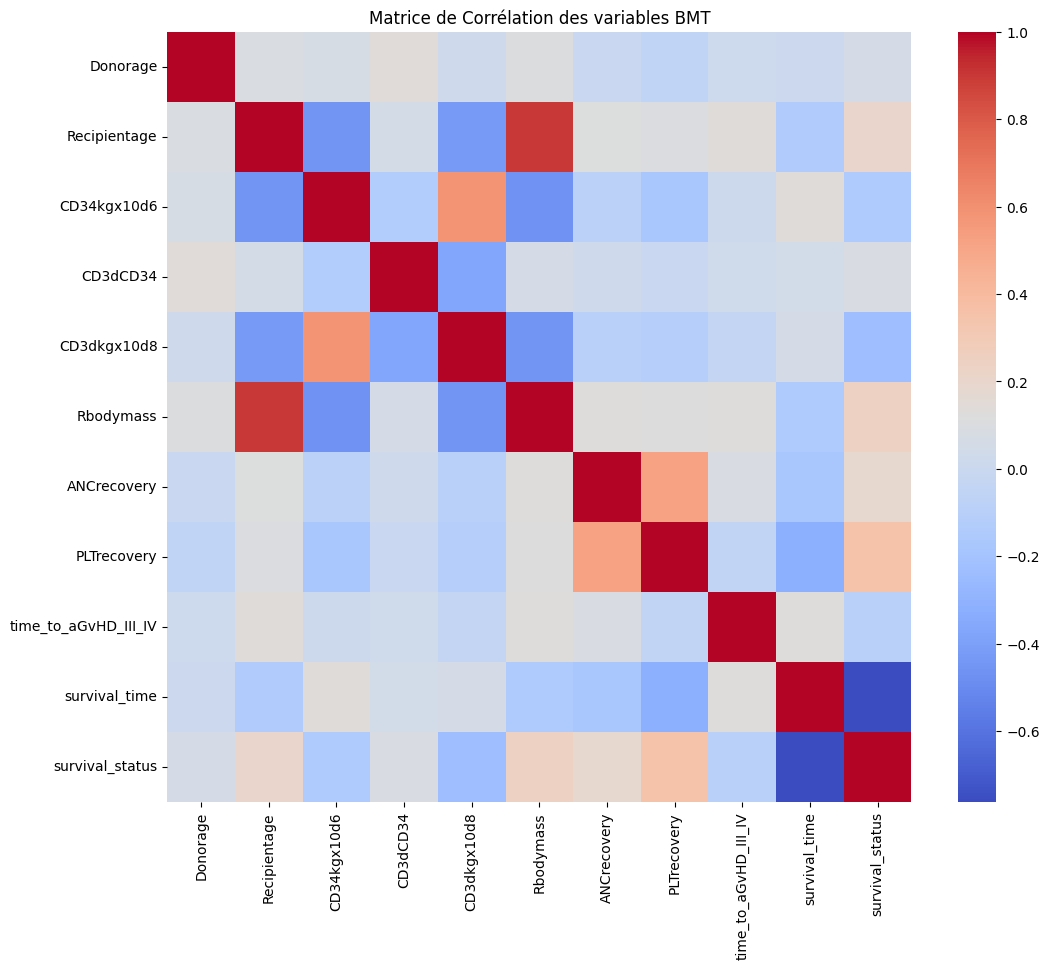

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation des variables BMT")
plt.show()

In [23]:
import numpy as np

# Calculer la matrice de corrélation absolue
corr_matrix = df.select_dtypes(include=[np.number]).corr().abs()

# Sélectionner le triangle supérieur de la matrice (pour éviter les doublons)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Trouver les colonnes avec une corrélation supérieure à 0.85
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]

print(f"Variables redondantes à supprimer : {to_drop}")

# Suppression effective
df_filtered = df.drop(columns=to_drop)

Variables redondantes à supprimer : ['Rbodymass']


In [24]:
# On regarde la corrélation de toutes les variables avec la cible 'survival_status'
target_corr = corr_matrix['survival_status'].sort_values(ascending=False)

print("Lien des variables avec la survie :")
print(target_corr)

# Stratégie : On pourrait écarter celles qui sont < 0.05 (très faibles)
weak_features = target_corr[target_corr < 0.05].index.tolist()
print(f"Variables avec un impact très faible : {weak_features}")

Lien des variables avec la survie :
survival_status         1.000000
survival_time           0.761462
PLTrecovery             0.346395
Rbodymass               0.238110
CD3dkgx10d8             0.232331
Recipientage            0.203406
ANCrecovery             0.181569
CD34kgx10d6             0.146653
time_to_aGvHD_III_IV    0.100601
CD3dCD34                0.089868
Donorage                0.060384
Name: survival_status, dtype: float64
Variables avec un impact très faible : []


In [25]:
# Focus sur la dose de cellules CD34
print(f"Corrélation CD34kgx10d6 / Survie : {corr_matrix.loc['CD34kgx10d6', 'survival_status']:.4f}")

Corrélation CD34kgx10d6 / Survie : 0.1467


In [13]:
import sys
sys.path.append('../') # Permet à Python de trouver le dossier 'src'

from src.data_processing import handle_missing_values

# 1. Utiliser la fonction pour nettoyer ton tableau
df_ml = handle_missing_values(df)

# 2. Continuer avec la préparation habituelle
df_ml = df_ml.copy()
for col in df_ml.select_dtypes(include=['object']).columns:
    df_ml[col] = df_ml[col].astype('category').cat.codes

X = df_ml.drop(['survival_status', 'survival_time'], axis=1)
y = df_ml['survival_status']

# 3. Lancer SMOTE avec la petite correction de sécurité
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42, k_neighbors=1) # On garde k_neighbors=1 par sécurité
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Données nettoyées et équilibrées !")

Données nettoyées et équilibrées !


In [14]:
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score

# Liste pour stocker les scores
summary_data = []

for name, model in models.items():
    # Entraînement et prédictions
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Récupération du rapport sous forme de dictionnaire pour extraire les chiffres
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Extraction des scores pour la classe '0.0' (Décès) en pourcentage
    recall_0 = report['0.0']['recall'] * 100
    precision_0 = report['0.0']['precision'] * 100
    f1_0 = report['0.0']['f1-score'] * 100
    auc = roc_auc_score(y_test, y_proba) * 100
    
    # Ajout à notre liste
    summary_data.append({
        "Modèle": name,
        "Rappel (Décès) %": f"{recall_0:.1f}%",
        "Précision (Décès) %": f"{precision_0:.1f}%",
        "F1-Score (Décès) %": f"{f1_0:.1f}%",
        "ROC-AUC %": f"{auc:.1f}%"
    })

# Création et affichage du tableau final
df_results = pd.DataFrame(summary_data)
print("=== COMPARAISON FINALE DES MODÈLES ===")
print(df_results.to_string(index=False))

=== COMPARAISON FINALE DES MODÈLES ===
       Modèle Rappel (Décès) % Précision (Décès) % F1-Score (Décès) % ROC-AUC %
Random Forest            81.0%               70.8%              75.6%     71.0%
      XGBoost            76.2%               69.6%              72.7%     73.4%
          SVM            71.4%               55.6%              62.5%     61.1%
